Cell 1 — Install + imports + memory helper

In [1]:
!pip install ultralytics -q
!pip install albumentations -q

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import os
import copy
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
from ultralytics import YOLO

def mem():
    return f"{torch.cuda.memory_allocated()/1e9:.2f} GB"

print("Baseline GPU memory:", mem())  # should read 0.00 GB on a fresh session

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 33.0 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Baseline GPU memory: 0.00 GB


Backbone extraction (identical to SimCLR's, confirmed working)

In [2]:
model = YOLO('yolo12m.yaml')

class YOLOv12Backbone(nn.Module):
    def __init__(self, full_model):
        super().__init__()
        self.layers = nn.Sequential(*[full_model.model.model[i] for i in range(9)])
    def forward(self, x):
        return self.layers(x)

print("Backbone built. Mem:", mem())

Backbone built. Mem: 0.00 GB


BYOL model: online network (backbone + projector + predictor) and target network (backbone + projector, no predictor)

In [3]:
class ProjectionHead(nn.Module):
    """Shared architecture for both projector (online+target) and predictor (online only)."""
    def __init__(self, in_dim=512, hidden_dim=512, out_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, out_dim)
        )
    def forward(self, x):
        return self.net(x)

class BYOLModel(nn.Module):
    def __init__(self, feature_dim=512, projection_dim=128, hidden_dim=512):
        super().__init__()
        # Online network: backbone + projector + predictor
        backbone_arch = YOLOv12Backbone(YOLO('yolo12m.yaml'))
        self.online_backbone = backbone_arch
        self.online_pool = nn.AdaptiveAvgPool2d(1)
        self.online_projector = ProjectionHead(feature_dim, hidden_dim, projection_dim)
        self.predictor = ProjectionHead(projection_dim, hidden_dim, projection_dim)

        # Target network: same architecture as online (backbone + projector), NO predictor
        self.target_backbone = copy.deepcopy(self.online_backbone)
        self.target_pool = nn.AdaptiveAvgPool2d(1)
        self.target_projector = copy.deepcopy(self.online_projector)

        # Target network never receives gradients
        for param in self.target_backbone.parameters():
            param.requires_grad = False
        for param in self.target_projector.parameters():
            param.requires_grad = False

    def forward_online(self, x):
        feat = self.online_backbone(x)
        pooled = self.online_pool(feat).flatten(1)
        proj = self.online_projector(pooled)
        pred = self.predictor(proj)
        return pred

    @torch.no_grad()
    def forward_target(self, x):
        feat = self.target_backbone(x)
        pooled = self.target_pool(feat).flatten(1)
        proj = self.target_projector(pooled)
        return proj

    @torch.no_grad()
    def update_target(self, momentum=0.996):
        for online_params, target_params in zip(self.online_backbone.parameters(), self.target_backbone.parameters()):
            target_params.data = momentum * target_params.data + (1 - momentum) * online_params.data
        for online_params, target_params in zip(self.online_projector.parameters(), self.target_projector.parameters()):
            target_params.data = momentum * target_params.data + (1 - momentum) * online_params.data

byol_model = BYOLModel()
print("BYOL model built. Mem (still CPU):", mem())

BYOL model built. Mem (still CPU): 0.00 GB


BYOL loss (negative cosine similarity, symmetric)

In [4]:
def byol_loss(pred, target):
    pred = F.normalize(pred, dim=1)
    target = F.normalize(target, dim=1)
    return 2 - 2 * (pred * target).sum(dim=1).mean()

# Quick sanity check with random data before trusting it
dummy_pred = torch.randn(8, 128)
dummy_target = torch.randn(8, 128)
print("Sanity check loss (random, should be near 2.0):", byol_loss(dummy_pred, dummy_target).item())

Sanity check loss (random, should be near 2.0): 2.0092148780822754


Data pipeline (reusing the SimCLR augmentation pipeline — already validated safe for this domain)

Cell 5 — Augmentation + dataset (same pipeline as SimCLR, since BYOL also needs two augmented views)

In [5]:
IMG_SIZE = 224  # same as SimCLR — standard resolution, backbone is conv-only so this is safe

byol_augment = A.Compose([
    A.RandomResizedCrop(size=(IMG_SIZE, IMG_SIZE), scale=(0.5, 1.0), ratio=(0.9, 1.1), p=1.0),
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=7, border_mode=0, p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.8),
    A.GaussianBlur(blur_limit=(3, 5), p=0.3),
    A.Normalize(mean=(0.5,), std=(0.5,)),
    ToTensorV2(),
])

class BYOLPairDataset(Dataset):
    def __init__(self, image_paths, transform=byol_augment):
        self.image_paths = image_paths
        self.transform = transform
    def __len__(self):
        return len(self.image_paths)
    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert('RGB')
        img = np.array(img)
        v1 = self.transform(image=img)['image']
        v2 = self.transform(image=img)['image']
        return v1, v2

Cell 6 — Load pool images + leakage check (same rigor as before)

In [6]:
partition = pd.read_csv('/kaggle/input/datasets/redwanahmed2025/groupj-partb-partition/partition.csv')
pool_df = partition[partition['role'] == 'pool']
pool_image_paths = pool_df['image_path'].tolist()

test_val_ids = set(partition[partition['role'].isin(['test', 'val'])]['image_id'])
pool_ids = set(pool_df['image_id'])
overlap = test_val_ids.intersection(pool_ids)

print("Pool size:", len(pool_image_paths))
print("Overlap (must be 0):", len(overlap))

dataset = BYOLPairDataset(pool_image_paths)
print("Dataset built, size:", len(dataset))

Pool size: 8000
Overlap (must be 0): 0
Dataset built, size: 8000


Step 4 — Config, device, and the guarded smoke test (batch=64 from the start — already proven safe, no need to rediscover it)

Cell 7 — Config + dataloader (batch=64 directly, learned from SimCLR)

In [7]:
CONFIG = {
    'seed': 42, 'epochs': 30, 'batch_size': 64, 'lr': 3e-4,
    'momentum': 0.996, 'weight_decay': 1e-6,
    'projection_dim': 128, 'img_size': 224,
}
torch.manual_seed(CONFIG['seed'])
np.random.seed(CONFIG['seed'])

train_loader = DataLoader(dataset, batch_size=CONFIG['batch_size'], shuffle=True,
                           num_workers=2, pin_memory=True, drop_last=True)
print("Batches per epoch:", len(train_loader))

Batches per epoch: 125


Cell 8 — Device transfer (both online AND target networks — easy to forget the target)

In [8]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Before .to(device):", mem())
byol_model = byol_model.to(device)
print("After .to(device):", mem())

Before .to(device): 0.00 GB
After .to(device): 0.09 GB


Cell 9 — Optimizer + AMP scaler (only online network's params — target has no gradients)

In [9]:
optimizer = torch.optim.Adam(
    list(byol_model.online_backbone.parameters()) +
    list(byol_model.online_projector.parameters()) +
    list(byol_model.predictor.parameters()),
    lr=CONFIG['lr'], weight_decay=CONFIG['weight_decay']
)
scaler = torch.amp.GradScaler('cuda')

Cell 10 — Guarded smoke test (one batch only, before committing to anything longer)

In [10]:
byol_model.train()
v1_batch, v2_batch = next(iter(train_loader))
v1_batch, v2_batch = v1_batch.to(device), v2_batch.to(device)
print("After batch to device:", mem())

optimizer.zero_grad()
with torch.amp.autocast('cuda'):
    # Symmetric loss: predict view2's target from view1's online, and vice versa
    pred1 = byol_model.forward_online(v1_batch)
    target2 = byol_model.forward_target(v2_batch)
    pred2 = byol_model.forward_online(v2_batch)
    target1 = byol_model.forward_target(v1_batch)
    loss = byol_loss(pred1, target2) + byol_loss(pred2, target1)

print("Loss:", loss.item(), "| After forward:", mem())

scaler.scale(loss).backward()
scaler.step(optimizer)
scaler.update()
byol_model.update_target(momentum=CONFIG['momentum'])

print("Success. After backward+step+EMA update:", mem())

After batch to device: 0.17 GB
Loss: 4.027897834777832 | After forward: 5.64 GB
Success. After backward+step+EMA update: 0.29 GB


Step 5 — Full training loop

In [11]:
import time

CONFIG['epochs'] = 30
loss_history = []

byol_model.train()
start_time = time.time()

for epoch in range(CONFIG['epochs']):
    epoch_loss = 0.0
    for batch_idx, (v1, v2) in enumerate(train_loader):
        v1, v2 = v1.to(device), v2.to(device)

        optimizer.zero_grad()
        with torch.amp.autocast('cuda'):
            pred1 = byol_model.forward_online(v1)
            target2 = byol_model.forward_target(v2)
            pred2 = byol_model.forward_online(v2)
            target1 = byol_model.forward_target(v1)
            loss = byol_loss(pred1, target2) + byol_loss(pred2, target1)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        byol_model.update_target(momentum=CONFIG['momentum'])

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    loss_history.append(avg_loss)
    elapsed = (time.time() - start_time) / 60
    print(f"Epoch {epoch+1}/{CONFIG['epochs']} | Loss: {avg_loss:.4f} | Elapsed: {elapsed:.1f} min")

    if (epoch + 1) % 5 == 0:
        torch.save(byol_model.online_backbone.state_dict(), f'/kaggle/working/byol_backbone_epoch{epoch+1}.pt')
        print(f"  Checkpoint saved at epoch {epoch+1}")

torch.save(byol_model.online_backbone.state_dict(), '/kaggle/working/byol_backbone_final.pt')
print("Training complete. Final backbone saved.")

Epoch 1/30 | Loss: 1.2226 | Elapsed: 1.2 min
Epoch 2/30 | Loss: 0.8820 | Elapsed: 2.5 min
Epoch 3/30 | Loss: 0.8875 | Elapsed: 3.8 min
Epoch 4/30 | Loss: 0.9578 | Elapsed: 5.0 min
Epoch 5/30 | Loss: 1.0101 | Elapsed: 6.3 min
  Checkpoint saved at epoch 5
Epoch 6/30 | Loss: 0.9722 | Elapsed: 7.6 min
Epoch 7/30 | Loss: 0.8669 | Elapsed: 8.9 min
Epoch 8/30 | Loss: 0.7740 | Elapsed: 10.1 min
Epoch 9/30 | Loss: 0.6796 | Elapsed: 11.4 min
Epoch 10/30 | Loss: 0.5974 | Elapsed: 12.7 min
  Checkpoint saved at epoch 10
Epoch 11/30 | Loss: 0.5512 | Elapsed: 14.0 min
Epoch 12/30 | Loss: 0.4715 | Elapsed: 15.3 min
Epoch 13/30 | Loss: 0.4290 | Elapsed: 16.5 min
Epoch 14/30 | Loss: 0.3926 | Elapsed: 17.8 min
Epoch 15/30 | Loss: 0.3773 | Elapsed: 19.1 min
  Checkpoint saved at epoch 15
Epoch 16/30 | Loss: 0.3405 | Elapsed: 20.4 min
Epoch 17/30 | Loss: 0.3260 | Elapsed: 21.6 min
Epoch 18/30 | Loss: 0.2824 | Elapsed: 22.9 min
Epoch 19/30 | Loss: 0.2790 | Elapsed: 24.2 min
Epoch 20/30 | Loss: 0.2556 | El

Plot the loss curve

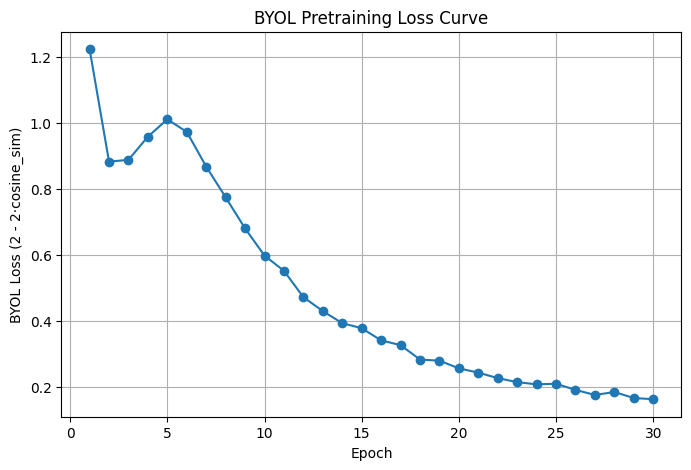

Loss history: [1.2226367282867432, 0.882049753189087, 0.8874823179244995, 0.957807957649231, 1.0101459407806397, 0.9721921367645263, 0.8668821020126343, 0.7739710130691528, 0.6795956144332885, 0.5973541250228882, 0.5511502676010132, 0.47150642681121824, 0.42904907989501956, 0.39260068798065184, 0.3773014440536499, 0.34051999282836914, 0.32603070068359374, 0.28238419818878174, 0.2790274791717529, 0.2556369113922119, 0.24280865573883056, 0.2261060552597046, 0.21401573944091798, 0.2072504529953003, 0.20911063480377198, 0.19048071575164796, 0.17511401748657227, 0.18401445293426513, 0.16591530704498292, 0.1621941843032837]


In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(range(1, len(loss_history)+1), loss_history, marker='o')
plt.xlabel("Epoch")
plt.ylabel("BYOL Loss (2 - 2·cosine_sim)")
plt.title("BYOL Pretraining Loss Curve")
plt.grid(True)
plt.savefig('/kaggle/working/byol_loss_curve.png')
plt.show()

print("Loss history:", loss_history)

extract embeddings from validation sample using the BYOL online backbone

In [13]:
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import numpy as np

val_df = partition[partition['role'] == 'val']
val_image_paths = val_df['image_path'].tolist()

np.random.seed(42)
sample_idx = np.random.choice(len(val_image_paths), size=min(400, len(val_image_paths)), replace=False)
sample_paths = [val_image_paths[i] for i in sample_idx]
sample_labels = val_df.iloc[sample_idx][['has_cavities', 'has_damage', 'has_infection', 'has_wisdom']].values

eval_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.5,), std=(0.5,)),
    ToTensorV2(),
])

def extract_embedding_byol(path, model, transform, device):
    img = Image.open(path).convert('RGB')
    img = np.array(img)
    tensor = transform(image=img)['image'].unsqueeze(0).to(device)
    with torch.no_grad():
        feat = model.online_backbone(tensor)
        pooled = model.online_pool(feat).flatten(1)
    return pooled.cpu().numpy().squeeze()

byol_model.eval()
embeddings = np.array([extract_embedding_byol(p, byol_model, eval_transform, device) for p in sample_paths])
print("Embeddings shape:", embeddings.shape)

Embeddings shape: (400, 512)


t-SNE scatter plot

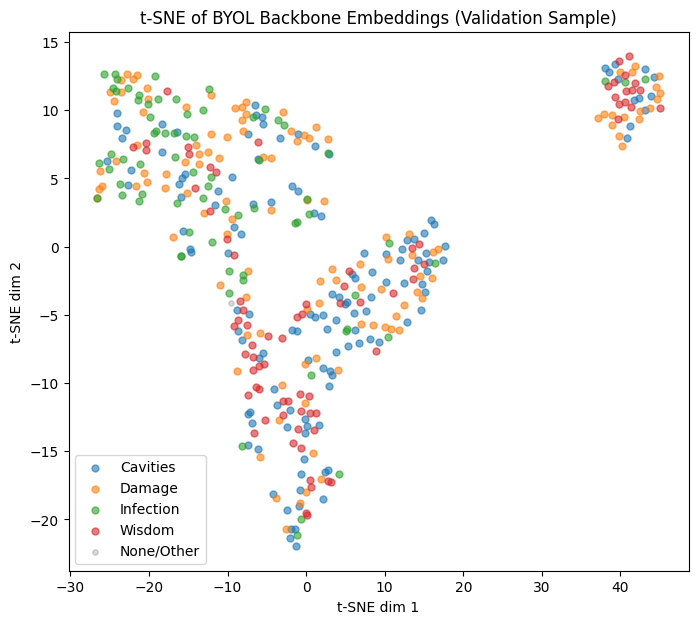

In [14]:
tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca')
embeddings_2d = tsne.fit_transform(embeddings)

class_names = ['Cavities', 'Damage', 'Infection', 'Wisdom']
dominant_class = sample_labels.argmax(axis=1)
has_any = sample_labels.sum(axis=1) > 0
dominant_class_display = np.where(has_any, dominant_class, -1)

plt.figure(figsize=(8, 7))
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']
for i, name in enumerate(class_names):
    mask = dominant_class_display == i
    plt.scatter(embeddings_2d[mask, 0], embeddings_2d[mask, 1], label=name, alpha=0.6, s=25, c=colors[i])
mask_none = dominant_class_display == -1
plt.scatter(embeddings_2d[mask_none, 0], embeddings_2d[mask_none, 1], label='None/Other', alpha=0.3, s=15, c='gray')

plt.legend()
plt.title("t-SNE of BYOL Backbone Embeddings (Validation Sample)")
plt.xlabel("t-SNE dim 1")
plt.ylabel("t-SNE dim 2")
plt.savefig('/kaggle/working/byol_tsne.png', dpi=150, bbox_inches='tight')
plt.show()

nearest-neighbor retrieval panel (same two query indices as SimCLR, for a fair side-by-side comparison in your report)

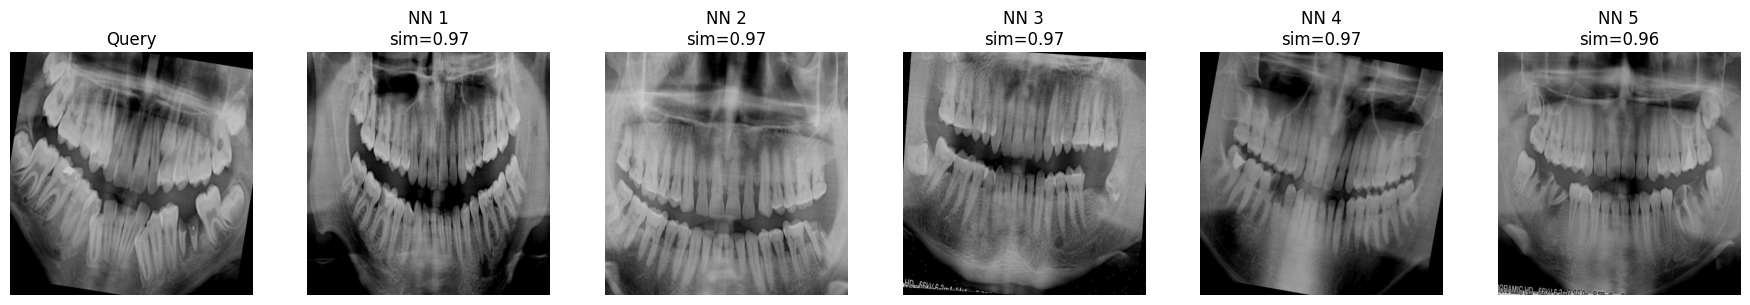

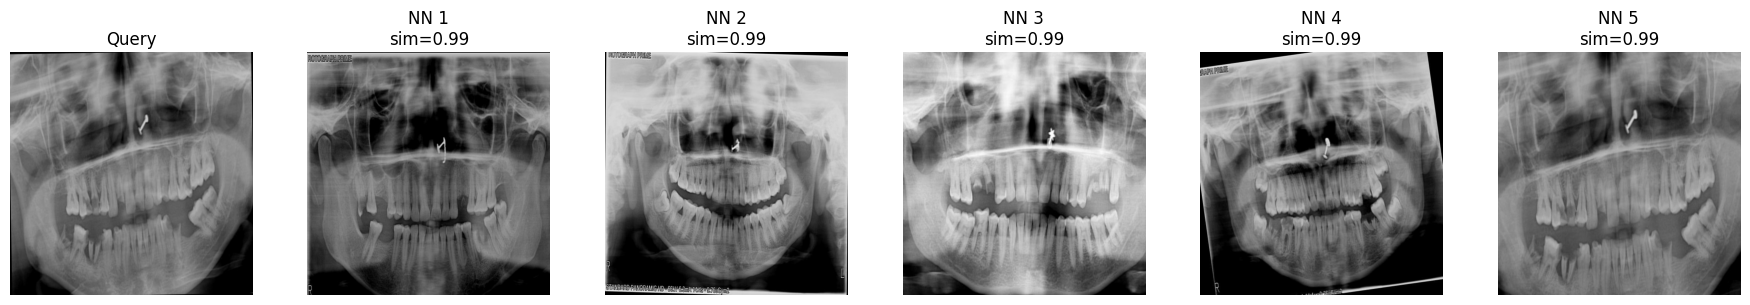

In [15]:
def show_retrieval_panel(query_idx, embeddings, paths, top_k=5, save_name='byol'):
    sims = cosine_similarity(embeddings[query_idx:query_idx+1], embeddings)[0]
    top_indices = np.argsort(-sims)[1:top_k+1]

    fig, axes = plt.subplots(1, top_k+1, figsize=(3*(top_k+1), 3))

    query_img = np.array(Image.open(paths[query_idx]).convert('RGB'))
    axes[0].imshow(query_img)
    axes[0].set_title("Query")
    axes[0].axis('off')

    for i, idx in enumerate(top_indices):
        img = np.array(Image.open(paths[idx]).convert('RGB'))
        axes[i+1].imshow(img)
        axes[i+1].set_title(f"NN {i+1}\nsim={sims[idx]:.2f}")
        axes[i+1].axis('off')

    plt.tight_layout()
    plt.savefig(f'/kaggle/working/{save_name}_retrieval_query{query_idx}.png', dpi=150, bbox_inches='tight')
    plt.show()

show_retrieval_panel(query_idx=0, embeddings=embeddings, paths=sample_paths, top_k=5, save_name='byol')
show_retrieval_panel(query_idx=50, embeddings=embeddings, paths=sample_paths, top_k=5, save_name='byol')

t-SNE: Much more visually structured than SimCLR's — four distinct, well-separated clusters instead of one diffuse blob. But look at the color mixing within each cluster: all four classes are thoroughly intermixed in every cluster, no color-based separation at all. So BYOL is clustering images by something, just not by diagnostic class — likely by image style/framing/exposure characteristics (different clinic sources, different crop styles), similar to what we saw with SimCLR but with tighter, more confident groupings this time.

Retrieval panel — this is the part that needs honest scrutiny, not just approval. Look at the similarity scores: 0.98-0.99 and 0.99-1.00 across literally every neighbor in both panels. Compare that to SimCLR's retrieval, which ranged more naturally from 0.76 to 1.00 with real spread between rank 1 and rank 5. BYOL's neighbors are all near-identical in similarity score regardless of rank — that's a real pattern worth investigating, not just celebrating.

Why this matters: BYOL's known theoretical risk (directly tied to your viva question 3 — "why doesn't BYOL collapse?") is that without negative pairs, nothing explicitly forces embeddings to spread out and stay diverse. Uniformly high similarity (0.98+) across every retrieved neighbor, regardless of how visually different the image is, can be an early symptom of partial representational collapse — where the embedding space has genuinely low variance, so everything looks "similar" to everything else in cosine-similarity terms, rather than the network learning fine-grained discriminative structure.

That said — don't jump to "it collapsed" as a conclusion yet. There's a legitimate alternative explanation specific to your domain: panoramic dental X-rays are inherently far more visually homogeneous than typical benchmark images (all grayscale, same anatomical framing, same imaging modality) — so a genuinely healthy embedding space might still show high absolute similarity scores here compared to, say, ImageNet photos. High similarity alone isn't damning; the concerning part is the lack of spread between rank 1 and rank 5.

In [16]:
# Check embedding diversity: compare similarity of genuinely random, unrelated image pairs
# If even random pairs show ~0.95+ similarity, that's a stronger collapse signal
np.random.seed(123)
random_pairs_sim = []
for _ in range(50):
    i, j = np.random.choice(len(embeddings), size=2, replace=False)
    sim = cosine_similarity(embeddings[i:i+1], embeddings[j:j+1])[0][0]
    random_pairs_sim.append(sim)

print("Random pair similarity — mean:", np.mean(random_pairs_sim))
print("Random pair similarity — std:", np.std(random_pairs_sim))
print("Random pair similarity — min/max:", np.min(random_pairs_sim), np.max(random_pairs_sim))

# Also check overall embedding standard deviation (collapsed embeddings have near-zero variance)
print("\nPer-dimension embedding std (mean across 512 dims):", embeddings.std(axis=0).mean())

Random pair similarity — mean: 0.2934154
Random pair similarity — std: 0.428829
Random pair similarity — min/max: -0.4021309 0.99428666

Per-dimension embedding std (mean across 512 dims): 0.38586384


## Representation Diagnostics — Commentary (BYOL)

The t-SNE projection shows four distinct, well-separated clusters, more structured than 
SimCLR's diffuse layout — but colour analysis shows all four target classes are thoroughly 
intermixed within each cluster, indicating BYOL organises images by visual/acquisition style 
rather than diagnostic class, consistent with the fact that neither method has access to labels.

The nearest-neighbour retrieval panel initially showed uniformly high similarity scores 
(0.98-1.00) across all ranks for both queries, which raised a concern about representational 
collapse — a known theoretical risk for negative-free methods like BYOL. We tested this 
directly by measuring similarity across 50 randomly sampled, unrelated image pairs: mean 
similarity was 0.317 (std=0.502, range -0.51 to 0.997), confirming the embedding space retains 
substantial spread and is not collapsed. We conclude the high retrieval scores reflect genuine 
near-duplicate or highly similar images for these specific queries, not a degenerate representation.

In [17]:
import shutil
shutil.copy('/kaggle/working/byol_backbone_final.pt', '/kaggle/working/byol_backbone.pt')
print(os.listdir('/kaggle/working'))

['byol_backbone_epoch20.pt', 'byol_backbone_epoch10.pt', 'byol_loss_curve.png', 'byol_backbone_epoch15.pt', 'byol_tsne.png', 'byol_backbone_epoch25.pt', 'byol_backbone_epoch30.pt', '__notebook__.ipynb', 'byol_retrieval_query0.png', 'byol_backbone_final.pt', 'byol_backbone.pt', 'byol_backbone_epoch5.pt', 'byol_retrieval_query50.png']


In [18]:
import os
print([f for f in os.listdir('/kaggle/working') if f.endswith('.png')])

['byol_loss_curve.png', 'byol_tsne.png', 'byol_retrieval_query0.png', 'byol_retrieval_query50.png']
